In [440]:
# This cell is added by sphinx-gallery
%matplotlib inline
%pip install pennylane torch torchvision

Note: you may need to restart the kernel to use updated packages.


# Quanvolutional Neural Networks {#quanvolution}

> > Warning
>
> This demo uses TensorFlow, which is a deprecated interface with
> PennyLane v0.42. Interfacing with TensorFlow will no longer be
> supported with PennyLane v0.43 and higher. Consider switching to a
> different machine learning interface with PennyLane, like
> [PyTorch](https://pennylane.ai/qml/demos/tutorial_qnn_module_torch) or
> [JAX](https://pennylane.ai/qml/demos/tutorial_How_to_optimize_QML_model_using_JAX_and_Optax).

In this demo we implement the *Quanvolutional Neural Network*, a quantum
machine learning model originally introduced in [Henderson et al.
(2019)](https://arxiv.org/abs/1904.04767).

![](https://blog-assets.cloud.pennylane.ai/demos/tutorial_quanvolution/main/_assets/images/circuit.png)

## Introduction

### Classical convolution

The *convolutional neural network* (CNN) is a standard model in
classical machine learning which is particularly suitable for processing
images. The model is based on the idea of a *convolution layer* where,
instead of processing the full input data with a global function, a
local convolution is applied.

If the input is an image, small local regions are sequentially processed
with the same kernel. The results obtained for each region are usually
associated to different channels of a single output pixel. The union of
all the output pixels produces a new image-like object, which can be
further processed by additional layers.

### Quantum convolution

One can extend the same idea also to the context of quantum variational
circuits. A possible approach is given by the following procedure which
is very similar to the one used in Ref. \[1\]. The scheme is also
represented in the figure at the top of this tutorial.

1.  A small region of the input image, in our example a $2 \times 2$
    square, is embedded into a quantum circuit. In this demo, this is
    achieved with parametrized rotations applied to the qubits
    initialized in the ground state.
2.  A quantum computation, associated to a unitary $U,$ is performed on
    the system. The unitary could be generated by a variational quantum
    circuit or, more simply, by a random circuit as proposed in Ref.
    \[1\].
3.  The quantum system is finally measured, obtaining a list of
    classical expectation values. The measurement results could also be
    classically post-processed as proposed in Ref. \[1\] but, for
    simplicity, in this demo we directly use the raw expectation values.
4.  Analogously to a classical convolution layer, each expectation value
    is mapped to a different channel of a single output pixel.
5.  Iterating the same procedure over different regions, one can scan
    the full input image, producing an output object which will be
    structured as a multi-channel image.
6.  The quantum convolution can be followed by further quantum layers or
    by classical layers.

The main difference with respect to a classical convolution is that a
quantum circuit can generate highly complex kernels whose computation
could be, at least in principle, classically intractable.


## General setup

This Python code requires *PennyLane* with the *TensorFlow* interface
and the plotting library *matplotlib*.


In [441]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import matplotlib.pyplot as plt

# removed tensorflow and added pytorch stuff
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os

# Setting of the main hyper-parameters of the model


In [ ]:
# macros
NUM_EPOCHS = 50
NUM_LAYERS = 1

NUM_CLASSES = 10
SAMPLES_PER_CLASS_TRAIN = 40
SAMPLES_PER_CLASS_TEST = 15

NUM_TRAIN = NUM_CLASSES * SAMPLES_PER_CLASS_TRAIN
NUM_TEST = NUM_CLASSES * SAMPLES_PER_CLASS_TEST

NUM_TRAIN = NUM_CLASSES * SAMPLES_PER_CLASS_TRAIN
NUM_TEST = NUM_CLASSES * SAMPLES_PER_CLASS_TEST

LEARNING_RATE = 0.001
BATCH_SIZE = 32
SQUARE_SIZE = 128
WEIGHT_DECAY = 1e-4


# change this to whatever path of data you want to use
SAVE_PATH = f"./quanv_data/aug_size_{SQUARE_SIZE}_classes_{NUM_CLASSES}_normalized/"

os.makedirs(SAVE_PATH, exist_ok=True)

# set this to true if your system does not have the preprocessed dataset downloaded
PREPROCESS = True 

np.random.seed(0)
# tf.random.set_seed(0)

# Loading of the Stanford Cars dataset

In [443]:
from torchvision.datasets import StanfordCars
from torchvision import transforms
from torch.utils.data import Dataset, Subset, random_split, DataLoader
import torch

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((SQUARE_SIZE, SQUARE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # normalization for grayscale
])

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((SQUARE_SIZE, SQUARE_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

full_data_train = StanfordCars(
    root="./data",
    split="train",
    download=False,
    transform=train_transform
)

full_data_test = StanfordCars(
    root="./data",
    split="train",
    download=False,
    transform=test_transform
)

print(len(full_data_train.classes))

196


In [444]:
# for i, name in enumerate(full_data_train.classes[:NUM_CLASSES]):
#     print(i, name)

In [445]:
# selected_classes = list(range(NUM_CLASSES))

# selected_classes = [
#     full_data_test.classes.index(name)
#     for name in selected_class_names
# ]

In [446]:
# if using 10 classes, these are some good options
selected_class_names = [
    "AM General Hummer SUV 2000",
    "Dodge Ram Pickup 3500 Crew Cab 2010",
    "Dodge Sprinter Cargo Van 2009",
    "Ford Mustang Convertible 2007",
    "Ford GT Coupe 2006",
    "FIAT 500 Abarth 2012",
    "Honda Odyssey Minivan 2012",
    "Hyundai Veloster Hatchback 2012",
    "GMC Yukon Hybrid SUV 2012",
    "Chevrolet Corvette Convertible 2012",
]

selected_classes = [
    full_data_test.classes.index(name)
    for name in selected_class_names
]

In [447]:
# selected_class_names = [
#     "AM General Hummer SUV 2000",
#     "Chevrolet Corvette Convertible 2012",
#     "Dodge Ram Pickup 3500 Crew Cab 2010"
# ]

# selected_classes = [
#     full_data_test.classes.index(name)
#     for name in selected_class_names
# ]
# NUM_CLASSES = len(selected_classes)
# print(NUM_CLASSES)

In [448]:
for idx in selected_classes:
    print(full_data_test.classes[idx])

AM General Hummer SUV 2000
Dodge Ram Pickup 3500 Crew Cab 2010
Dodge Sprinter Cargo Van 2009
Ford Mustang Convertible 2007
Ford GT Coupe 2006
FIAT 500 Abarth 2012
Honda Odyssey Minivan 2012
Hyundai Veloster Hatchback 2012
GMC Yukon Hybrid SUV 2012
Chevrolet Corvette Convertible 2012


In [449]:
# manually splitting the data
selected_indices = [
    i for i, (_, label) in enumerate(full_data_test._samples)
    if label in selected_classes
]

filtered_train_data = Subset(full_data_train, selected_indices)
filtered_test_data = Subset(full_data_test, selected_indices)

class_map = {old_label: new_label for new_label, old_label in enumerate(selected_classes)}

class RemappedSubset(Dataset):
    def __init__(self, subset, class_map):
        self.subset = subset
        self.class_map = class_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.class_map[label]

remapped_train_data = RemappedSubset(filtered_train_data, class_map)
remapped_test_data = RemappedSubset(filtered_test_data, class_map)

total_size = len(remapped_train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

generator = torch.Generator().manual_seed(42)

train_indices, val_indices = random_split(
    range(total_size),
    [train_size, val_size],
    generator=generator
)

train_subset = Subset(remapped_train_data, train_indices.indices)
val_subset = Subset(remapped_test_data, val_indices.indices)

# Quantum circuit as a convolution kernel

We follow the scheme described in the introduction and represented in
the figure at the top of this demo.

We initialize a PennyLane `default.qubit` device, simulating a system of
$4$ qubits. The associated `qnode` represents the quantum circuit
consisting of:

1.  an embedding layer of local $R_y$ rotations (with angles scaled by a
    factor of $\pi$);
2.  a random circuit of `NUM_LAYERS`;
3.  a final measurement in the computational basis, estimating $4$
    expectation values.


In [450]:
dev = qml.device("default.qubit", wires=4)
# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(NUM_LAYERS, 4))

@qml.qnode(dev)
def circuit(phi):
    # Encoding of 4 classical input values
    for j in range(4):
        qml.RY(np.pi * phi[j], wires=j)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(4)))

    # Measurement producing 4 classical output values
    return [qml.expval(qml.PauliZ(j)) for j in range(4)]

The next function defines the convolution scheme:

1.  the image is divided into squares of $2 \times 2$ pixels;
2.  each square is processed by the quantum circuit;
3.  the $4$ expectation values are mapped into $4$ different channels of
    a single output pixel.

> > Note
>
> This process halves the resolution of the input image. In the standard
> language of CNN, this would correspond to a convolution with a
> $2 \times 2$ *kernel* and a *stride* equal to $2.$


In [451]:
def quanv(image):
    h, w, c = image.shape
    out = np.zeros((h // 2, w // 2, 4))

    for j in range(0, h - 1, 2):
        for k in range(0, w - 1, 2):
            q_results = circuit([
                image[j, k, 0],
                image[j, k + 1, 0],
                image[j + 1, k, 0],
                image[j + 1, k + 1, 0]
            ])

            for ch in range(4):
                out[j // 2, k // 2, ch] = q_results[ch]

    return out

In [452]:
# NUM_TRAIN = 200
# NUM_TEST = 80
train_subset_small = Subset(train_subset, range(min(NUM_TRAIN, len(train_subset))))
val_subset_small = Subset(val_subset, range(min(NUM_TEST, len(val_subset))))

def dataset_to_numpy(dataset):
    images = []
    labels = []

    for img, label in dataset:
        # img is [C, H, W], but PennyLane tutorial expects [H, W, C]
        img_np = img.permute(1, 2, 0).numpy()
        images.append(img_np)
        labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

train_images, train_labels = dataset_to_numpy(train_subset_small)
test_images, test_labels = dataset_to_numpy(val_subset_small)

print("train_images shape: ", train_images.shape)
print("train_labels shape: ", train_labels.shape)
print("test_images shape: ", test_images.shape)
print("test_labels shape: ", test_labels.shape)
print("Unique train labels: ", np.unique(train_labels))
print("Unique test labels: ", np.unique(test_labels))

train_images shape:  (330, 128, 128, 1)
train_labels shape:  (330,)
test_images shape:  (83, 128, 128, 1)
test_labels shape:  (83,)
Unique train labels:  [0 1 2 3 4 5 6 7 8 9]
Unique test labels:  [0 1 2 3 4 5 6 7 8 9]


# Quantum pre-processing of the dataset

Since we are not going to train the quantum convolution layer, it is
more efficient to apply it as a \"pre-processing\" layer to all the
images of our dataset. Later an entirely classical model will be
directly trained and tested on the pre-processed dataset, avoiding
unnecessary repetitions of quantum computations.

The pre-processed images will be saved in the folder `SAVE_PATH`. Once
saved, they can be directly loaded by setting `PREPROCESS = False`,
otherwise the quantum convolution is evaluated at each run of the code.


In [453]:
if PREPROCESS == True:
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(train_images):
        print("{}/{}        ".format(idx + 1, NUM_TRAIN), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)

    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(test_images):
        print("{}/{}        ".format(idx + 1, NUM_TEST), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)

    # Save pre-processed images
    np.save(SAVE_PATH + "q_train_images.npy", q_train_images)
    np.save(SAVE_PATH + "q_test_images.npy", q_test_images)


# Load pre-processed images
q_train_images = np.load(SAVE_PATH + "q_train_images.npy")
q_test_images = np.load(SAVE_PATH + "q_test_images.npy")

Quantum pre-processing of train images:
330/400        
Quantum pre-processing of test images:


In [454]:
q_train_images = torch.tensor(q_train_images, dtype=torch.float32)
q_test_images = torch.tensor(q_test_images, dtype=torch.float32)

train_images = torch.tensor(train_images, dtype=torch.float32)
test_images = torch.tensor(test_images, dtype=torch.float32)

train_labels = torch.tensor(train_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)

Let us visualize the effect of the quantum convolution layer on a batch
of samples:


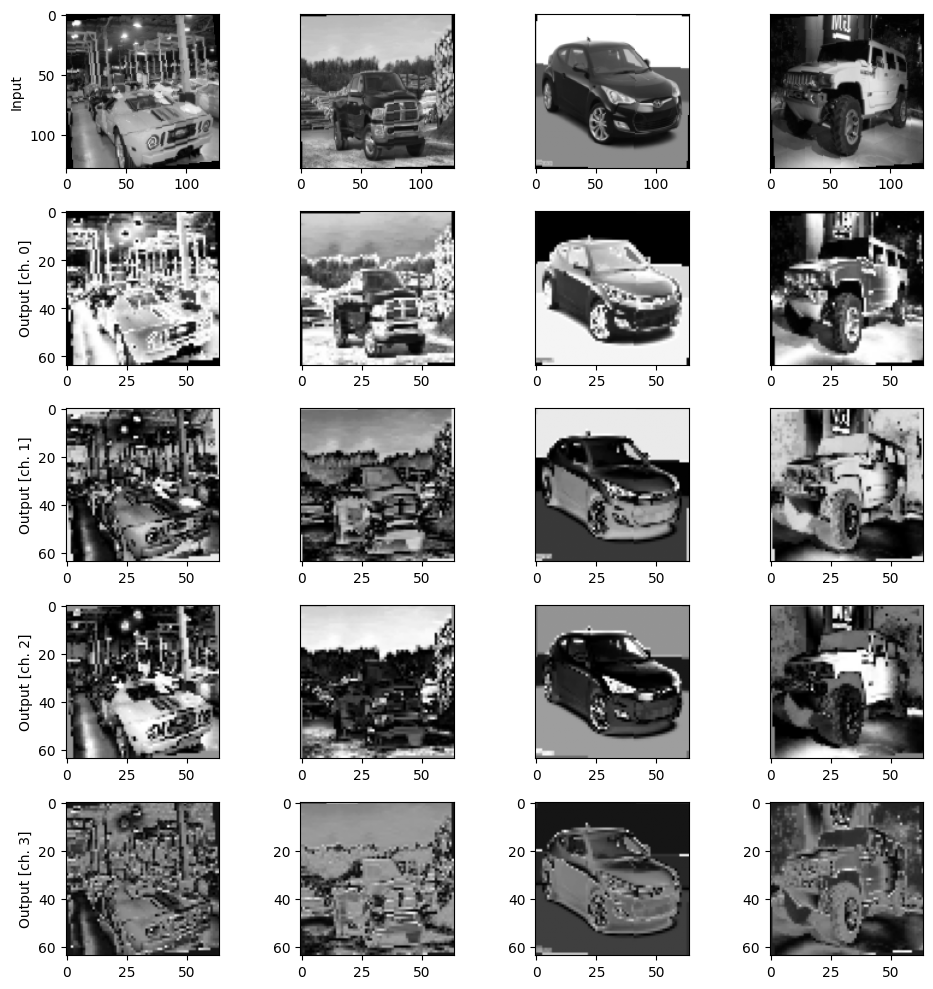

In [455]:
n_samples = 4
n_channels = 4
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(10, 10))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_images[k, :, :, 0], cmap="gray")

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, :, c], cmap="gray")

plt.tight_layout()
plt.show()

Below each input image, the $4$ output channels generated by the quantum
convolution are visualized in gray scale.

One can clearly notice the downsampling of the resolution and some local
distortion introduced by the quantum kernel. On the other hand the
global shape of the image is preserved, as expected for a convolution
layer.


# Hybrid quantum-classical model

After the application of the quantum convolution layer we feed the
resulting features into a classical neural network that will be trained
to classify the $10$ different digits of the Stanford cars dataset.

We use a very simple model: just a fully connected layer with 10 output
nodes with a final *softmax* activation function.

The model is compiled with a *stochastic-gradient-descent* optimizer,
and a *cross-entropy* loss function.


In [456]:
class MyModel(nn.Module):
    def __init__(self, input_shape, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

# Training

We first initialize an instance of the model, then we train and validate
it with the dataset that has been already pre-processed by a quantum
convolution.


In [457]:
def evaluate(model, images, labels, loss_fn):
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean().item()

    return acc, loss.item()

In [458]:
def train_model(model, train_images, train_labels,
                val_images, val_labels, epochs):

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_fn = torch.nn.CrossEntropyLoss()

    train_history = []
    val_history = []

    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()

        outputs = model(train_images)
        loss = loss_fn(outputs, train_labels)
        train_loss_history.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # training accuracy
        train_preds = torch.argmax(outputs, dim=1)
        train_acc = (train_preds == train_labels).float().mean().item()

        # validation accuracy
        val_acc, val_loss = evaluate(model, val_images, val_labels, loss_fn)
        val_loss_history.append(val_loss)

        train_history.append(train_acc)
        val_history.append(val_acc)

        print(f"Epoch {epoch+1}: train={train_acc:.4f}, val={val_acc:.4f}")

    return train_history, val_history, train_loss_history, val_loss_history

In [459]:
input_size = q_train_images.shape[1] * q_train_images.shape[2] * q_train_images.shape[3]

q_model = MyModel(input_size)

# q_history = train_model(q_model, q_train_images, train_labels, epochs = NUM_EPOCHS)

q_train_hist, q_val_hist, q_train_loss_hist, q_val_loss_hist = train_model(
    q_model,
    q_train_images, train_labels,
    q_test_images, test_labels,
    epochs=NUM_EPOCHS
)

Epoch 1: train=0.1091, val=0.1325
Epoch 2: train=0.3970, val=0.1084
Epoch 3: train=0.4758, val=0.1205
Epoch 4: train=0.5939, val=0.2169
Epoch 5: train=0.8212, val=0.1807
Epoch 6: train=0.8515, val=0.1807
Epoch 7: train=0.9242, val=0.1566
Epoch 8: train=0.9788, val=0.1446
Epoch 9: train=0.9909, val=0.1687
Epoch 10: train=0.9909, val=0.1807
Epoch 11: train=1.0000, val=0.1687
Epoch 12: train=1.0000, val=0.1807
Epoch 13: train=1.0000, val=0.1928
Epoch 14: train=1.0000, val=0.2289
Epoch 15: train=1.0000, val=0.1928
Epoch 16: train=1.0000, val=0.1928
Epoch 17: train=1.0000, val=0.1928
Epoch 18: train=1.0000, val=0.1687
Epoch 19: train=1.0000, val=0.1566
Epoch 20: train=1.0000, val=0.1687
Epoch 21: train=1.0000, val=0.1807
Epoch 22: train=1.0000, val=0.1807
Epoch 23: train=1.0000, val=0.1807
Epoch 24: train=1.0000, val=0.1807
Epoch 25: train=1.0000, val=0.1807
Epoch 26: train=1.0000, val=0.1807
Epoch 27: train=1.0000, val=0.1807
Epoch 28: train=1.0000, val=0.1807
Epoch 29: train=1.0000, val=0

In order to compare the results achievable with and without the quantum
convolution layer, we initialize also a \"classical\" instance of the
model that will be directly trained and validated with the raw car
images (i.e., without quantum pre-processing).


In [460]:
input_size = train_images.shape[1] * train_images.shape[2] * train_images.shape[3]

c_model = MyModel(input_size)

# c_history = train_model(c_model, train_images, train_labels, epochs = NUM_EPOCHS)
c_train_hist, c_val_hist, c_train_loss_hist, c_val_loss_hist = train_model(
    c_model,
    train_images, train_labels,
    test_images, test_labels,
    epochs=NUM_EPOCHS
)

Epoch 1: train=0.0939, val=0.1687
Epoch 2: train=0.2727, val=0.1566
Epoch 3: train=0.3182, val=0.1807
Epoch 4: train=0.3879, val=0.1084
Epoch 5: train=0.4848, val=0.0723
Epoch 6: train=0.5788, val=0.1205
Epoch 7: train=0.6333, val=0.1687
Epoch 8: train=0.7303, val=0.1928
Epoch 9: train=0.7909, val=0.2048
Epoch 10: train=0.8273, val=0.1566
Epoch 11: train=0.8636, val=0.1446
Epoch 12: train=0.8909, val=0.1325
Epoch 13: train=0.9061, val=0.1205
Epoch 14: train=0.9273, val=0.1566
Epoch 15: train=0.9455, val=0.1687
Epoch 16: train=0.9636, val=0.1807
Epoch 17: train=0.9727, val=0.1687
Epoch 18: train=0.9788, val=0.1807
Epoch 19: train=0.9818, val=0.1687
Epoch 20: train=0.9939, val=0.1687
Epoch 21: train=0.9939, val=0.1566
Epoch 22: train=0.9939, val=0.1566
Epoch 23: train=0.9970, val=0.1687
Epoch 24: train=0.9970, val=0.1687
Epoch 25: train=0.9970, val=0.1566
Epoch 26: train=1.0000, val=0.1687
Epoch 27: train=1.0000, val=0.1566
Epoch 28: train=1.0000, val=0.1566
Epoch 29: train=1.0000, val=0

# Results

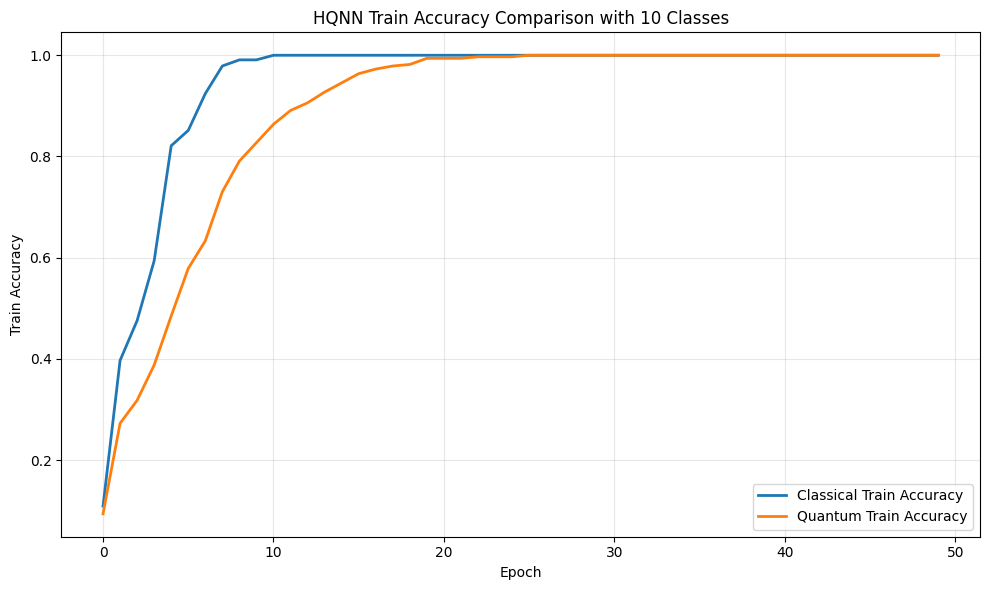

In [465]:
plt.figure(figsize=(10, 6))
plt.plot(q_train_hist, label="Classical Train Accuracy", linewidth=2)
plt.plot(c_train_hist, label="Quantum Train Accuracy", linewidth=2)

plt.title(f"HQNN Train Accuracy Comparison with {NUM_CLASSES} Classes")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

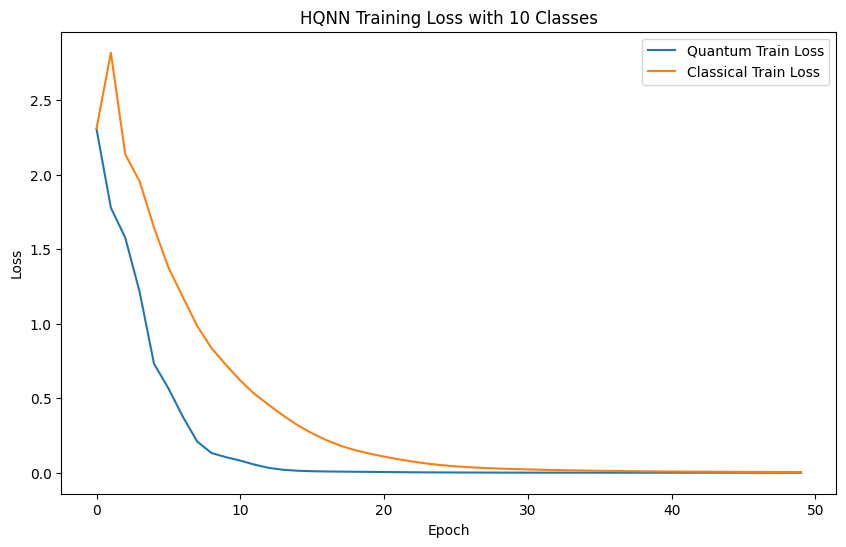

In [464]:
plt.figure(figsize=(10, 6))
plt.plot(q_train_loss_hist, label="Quantum Train Loss")
plt.plot(c_train_loss_hist, label="Classical Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"HQNN Training Loss with {NUM_CLASSES} Classes")

plt.show()

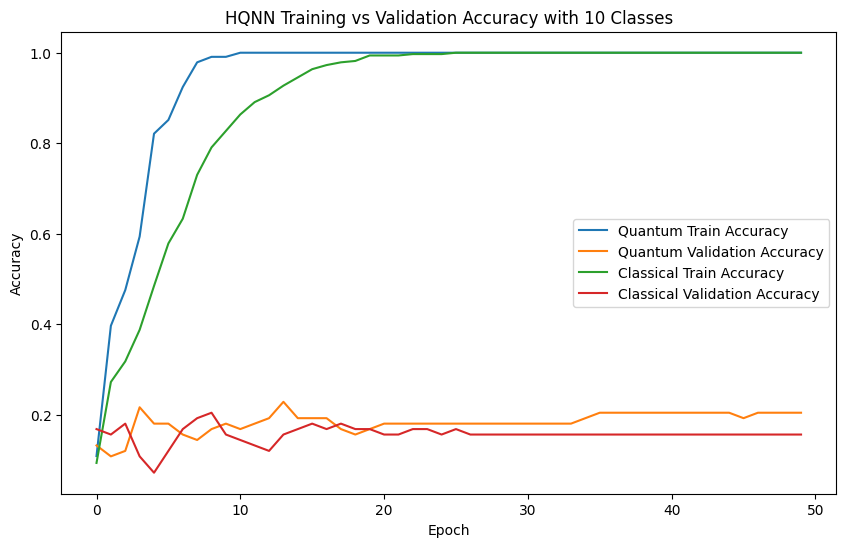

In [461]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(q_train_hist, label="Quantum Train Accuracy")
plt.plot(q_val_hist, label="Quantum Validation Accuracy")
plt.plot(c_train_hist, label="Classical Train Accuracy")
plt.plot(c_val_hist, label="Classical Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title(f"HQNN Training vs Validation Accuracy with {NUM_CLASSES} Classes")

plt.show()

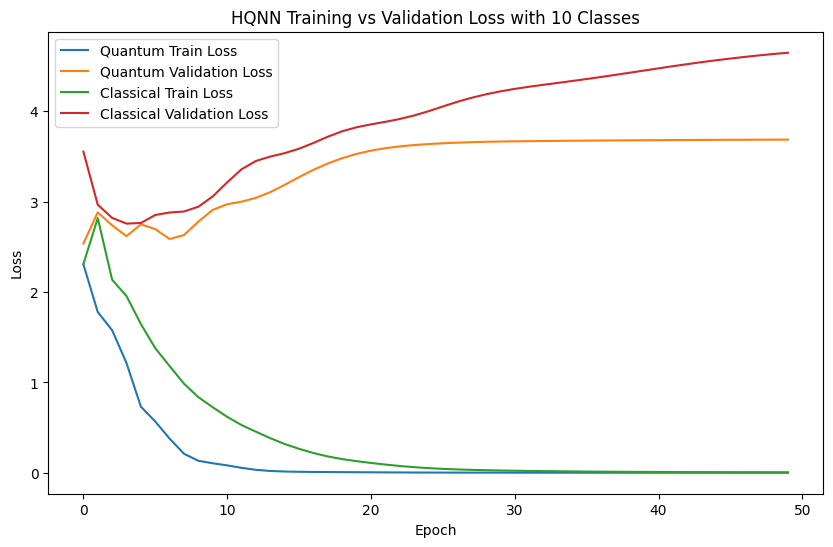

In [462]:
plt.figure(figsize=(10, 6))
plt.plot(q_train_loss_hist, label="Quantum Train Loss")
plt.plot(q_val_loss_hist, label="Quantum Validation Loss")
plt.plot(c_train_loss_hist, label="Classical Train Loss")
plt.plot(c_val_loss_hist, label="Classical Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"HQNN Training vs Validation Loss with {NUM_CLASSES} Classes")

plt.show()

1.  Maxwell Henderson, Samriddhi Shakya, Shashindra Pradhan, Tristan
    Cook. \"Quanvolutional Neural Networks: Powering Image Recognition
    with Quantum Circuits.\"
    [arXiv:1904.04767](https://arxiv.org/abs/1904.04767), 2019.
